# **Data Analysis Report**

## **Executive Summary**

$\newline$

This report aims to provide a brief overview into the data that has been collected and manipulated in order to make feasible to create a tennis Elo ranking system. Reading in the initial data, we have seen that several variable types are in the incorrect format and many others are simply unnecessary and redundant to what we are seeking to achieve. Other main findings include the fact that we encountered many missing value counts, and needed to adjust this accordingly and that the mean number of sets was just over three. It was also found out the most preferred court type (carpet) which had the highest average out of the data set. 

## **Introduction**

This data analysis focuses on preparing and exploring the historical tennis match data that will be used to compute ELO ratings. It aims to assess data quality, identify key patterns, and ensure the dataset is suitable for accurate rating calculations, visualisations, and predictions. This pre-processing step ranges from the initial data collection, interpreting data inconsistencies, anomalies and then becoming familiar with the distribution of data. Undergoing these steps poises ourselves to become more familiar with the data and places us in a good position to continue with the rest of the development.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## **Data Collection**

$\newline$

The dataset in use at this stage was collated from an existing dataset published on Kaggle. The dataset contains over 60,000 ATP matches between 2000 and 2025. Each match includes the tournament, date, type of tournament, whether the match was played indoors or not, type of court surface, round of the match, maximum number of sets in the match, participants in the match, winner, ranks of the participants, odds to win and match score. This dataset aligns with our goals and notion in beginning to create a tennis Elo ranking system. The format of the data came in as a CSV file and we have used Python pandas in this instance to allow the data to become machine readable. Due to the early stages nature of the development, we cannot provide any concrete biases regarding the data, however there have been some potential limitations that we may have to address as we progress further. This revolves around the static nature of the data. Tennis is a constantly evolving game, dynamic in nature and the data we collect does not allow for any dynamic changes. As such, in the near future it is likely that we may consider using an API that contains the same tennis data, but allows for frequent and dynamic changes.

In [2]:
df = pd.read_csv("./data/atp_tennis.csv")

In [3]:
df.shape

(65151, 17)

In [4]:
df.head()

,Tournament,Date,Series,Court,Surface,Round,Best of,Player_1,Player_2,Winner,Rank_1,Rank_2,Pts_1,Pts_2,Odd_1,Odd_2,Score
0,Australian Hardcourt Championships,2000-01-03,International,Outdoor,Hard,1st Round,3,Dosedel S.,Ljubicic I.,Dosedel S.,63,77,-1,-1,-1.0,-1.0,6-4 6-2
1,Australian Hardcourt Championships,2000-01-03,International,Outdoor,Hard,1st Round,3,Clement A.,Enqvist T.,Enqvist T.,56,5,-1,-1,-1.0,-1.0,3-6 3-6
2,Australian Hardcourt Championships,2000-01-03,International,Outdoor,Hard,1st Round,3,Escude N.,Baccanello P.,Escude N.,40,655,-1,-1,-1.0,-1.0,6-7 7-5 6-3
3,Australian Hardcourt Championships,2000-01-03,International,Outdoor,Hard,1st Round,3,Knippschild J.,Federer R.,Federer R.,87,65,-1,-1,-1.0,-1.0,1-6 4-6
4,Australian Hardcourt Championships,2000-01-03,International,Outdoor,Hard,1st Round,3,Fromberg R.,Woodbridge T.,Fromberg R.,81,198,-1,-1,-1.0,-1.0,7-6 5-7 6-4


## **Data Pre-processing**

$\newline$
Let's first check out the data types of each variable in our dataset. As mentioned there are currently over 60,000 records attached to the dataset, giving us a comprehensive and holistic view of the past tennis matches. Below we have identified the datatypes and we can see that most of them are formatted as objects or strings, and thus in order to make this data usable, many of these variables may need to be changed. There are 17 columns of data looking from the tournament, dates, series, court surface, rounds, best of (rounds), players, winner, ranks, points, odds of each player and the score of the match.

In [5]:
df.dtypes

Tournament     object
Date           object
Series         object
Court          object
Surface        object
Round          object
Best of         int64
Player_1       object
Player_2       object
Winner         object
Rank_1          int64
Rank_2          int64
Pts_1           int64
Pts_2           int64
Odd_1         float64
Odd_2         float64
Score          object
dtype: object

## **Data Analysis**

### **Data  Inconsistencies**


$\newline$
We note that our data contains entries across 2000-2025, but the stipulation that we have made in the development of this ranking system is that we look back only 20 years worth of data (i.e., 2004-2024) and as such the data needed to be amended to suit this. In addition, there are some data types that are not suitable; the Date variable was changed to a datetime object so we can filter and use the dates as times instead of strings. We then check for any missing values, duplicates and other inconsistencies that may hinder our data and remove any rows containing such. In the analysis of the data there appears to be an error regarding the minimum error for several of the columns (Rank_1, Rank_2, Pts_1, Pts_2, Odd_1 and Odd_2), wherein it is acting as a placeholder for a missing value. Discovering this, we have opted to replace it with NaN value instead as these may have been matches that were supposed to happen but didn't (i.e., poor weather conditions), or had early forfeitures, and the data is only based off complete matches. Similarly, it may be a result of improper documentation, such as the player may not have been ranked yet, or it was not part of a major ATP tournament so it did not get accounted for properly.

In [6]:
df["Date"] = pd.to_datetime(df["Date"])

Sort datetime values in chronological order

In [7]:
df.sort_values(by='Date', ascending=True)

,Tournament,Date,Series,Court,Surface,Round,Best of,Player_1,Player_2,Winner,Rank_1,Rank_2,Pts_1,Pts_2,Odd_1,Odd_2,Score
0,Australian Hardcourt Championships,2000-01-03,International,Outdoor,Hard,1st Round,3,Dosedel S.,Ljubicic I.,Dosedel S.,63,77,-1,-1,-1.00,-1.00,6-4 6-2
66,Qatar Open,2000-01-03,International,Outdoor,Hard,1st Round,3,El Aynaoui Y.,Dupuis A.,El Aynaoui Y.,33,78,-1,-1,-1.00,-1.00,4-6 6-3 6-2
65,Qatar Open,2000-01-03,International,Outdoor,Hard,1st Round,3,Arazi H.,Cherkasov A.,Cherkasov A.,35,206,-1,-1,-1.00,-1.00,2-6 4-6
64,Qatar Open,2000-01-03,International,Outdoor,Hard,1st Round,3,Caratti C.,Heuberger I.,Caratti C.,211,219,-1,-1,-1.00,-1.00,7-6 4-6 6-4
63,Qatar Open,2000-01-03,International,Outdoor,Hard,1st Round,3,Al-Alawi S.K.,Berasategui A.,Berasategui A.,-1,60,-1,-1,-1.00,-1.00,3-6 4-6
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
65146,Mutua Madrid Open,2025-05-01,Masters 1000,Outdoor,Clay,Quarterfinals,3,Draper J.,Arnaldi M.,Draper J.,6,44,3820,1240,1.29,3.75,6-0 6-4
65147,Mutua Madrid Open,2025-05-01,Masters 1000,Outdoor,Clay,Quarterfinals,3,Diallo G.,Musetti L.,Musetti L.,78,11,791,3200,4.50,1.20,4-6 3-6
65149,Mutua Madrid Open,2025-05-02,Masters 1000,Outdoor,Clay,Semifinals,3,Musetti L.,Draper J.,Draper J.,11,6,3200,3820,2.50,1.53,3-6 6-7
65148,Mutua Madrid Open,2025-05-02,Masters 1000,Outdoor,Clay,Semifinals,3,Ruud C.,Cerundolo F.,Ruud C.,15,21,2815,2225,1.80,2.00,6-4 7-5


The dataset used in this project seems to have historical tennis match records from 2000 to 2025, so the first thing we will do is limit the dataset to 2004 to 2024.

In [8]:
df.head()

,Tournament,Date,Series,Court,Surface,Round,Best of,Player_1,Player_2,Winner,Rank_1,Rank_2,Pts_1,Pts_2,Odd_1,Odd_2,Score
0,Australian Hardcourt Championships,2000-01-03,International,Outdoor,Hard,1st Round,3,Dosedel S.,Ljubicic I.,Dosedel S.,63,77,-1,-1,-1.0,-1.0,6-4 6-2
1,Australian Hardcourt Championships,2000-01-03,International,Outdoor,Hard,1st Round,3,Clement A.,Enqvist T.,Enqvist T.,56,5,-1,-1,-1.0,-1.0,3-6 3-6
2,Australian Hardcourt Championships,2000-01-03,International,Outdoor,Hard,1st Round,3,Escude N.,Baccanello P.,Escude N.,40,655,-1,-1,-1.0,-1.0,6-7 7-5 6-3
3,Australian Hardcourt Championships,2000-01-03,International,Outdoor,Hard,1st Round,3,Knippschild J.,Federer R.,Federer R.,87,65,-1,-1,-1.0,-1.0,1-6 4-6
4,Australian Hardcourt Championships,2000-01-03,International,Outdoor,Hard,1st Round,3,Fromberg R.,Woodbridge T.,Fromberg R.,81,198,-1,-1,-1.0,-1.0,7-6 5-7 6-4


In [9]:
df_filtered = df[(pd.DatetimeIndex(df['Date']).year >= 2004) & (pd.DatetimeIndex(df['Date']).year <= 2024)]

In [10]:
df_filtered.head()

,Tournament,Date,Series,Court,Surface,Round,Best of,Player_1,Player_2,Winner,Rank_1,Rank_2,Pts_1,Pts_2,Odd_1,Odd_2,Score
11251,AAPT Championships,2004-01-05,International,Outdoor,Hard,1st Round,3,Melzer J.,Spadea V.,Spadea V.,79,29,-1,-1,2.62,1.438333,6-7 2-6
11252,AAPT Championships,2004-01-05,International,Outdoor,Hard,1st Round,3,Dent T.,Horna L.,Dent T.,33,64,-1,-1,1.16,4.500000,6-2 6-3
11253,AAPT Championships,2004-01-05,International,Outdoor,Hard,1st Round,3,Ancic M.,Martin A.,Martin A.,74,54,-1,-1,1.72,2.000000,3-6 7-6 6-7
11254,AAPT Championships,2004-01-05,International,Outdoor,Hard,1st Round,3,Beck K.,Vahaly B.,Beck K.,66,75,-1,-1,1.83,1.830000,6-2 6-2
11255,AAPT Championships,2004-01-05,International,Outdoor,Hard,1st Round,3,Moodie W.,Nieminen J.,Nieminen J.,82,36,-1,-1,2.75,1.400000,6-4 6-7 5-7


In [11]:
df = df_filtered

Now we check for missing values

In [12]:
df.isnull().sum()

Tournament    0
Date          0
Series        0
Court         0
Surface       0
Round         0
Best of       0
Player_1      0
Player_2      0
Winner        0
Rank_1        0
Rank_2        0
Pts_1         0
Pts_2         0
Odd_1         0
Odd_2         0
Score         0
dtype: int64

Looks like we don't have any missing values. We also want to make sure we don't have duplicates. It would cause bias if we were to have a duplicated match, since the person who wins would have 1 extra win and the person who lost would have 1 extra loss (for example 2 of the same game).

In [13]:
df.duplicated().sum()

0

Let's have a look at a basic summary of the dataset

In [14]:
df.describe()

,Date,Best of,Rank_1,Rank_2,Pts_1,Pts_2,Odd_1,Odd_2
count,52942,52942.000000,52942.000000,52942.000000,52942.000000,52942.000000,52942.000000,52942.000000
mean,2014-02-12 11:17:45.543424768,3.381814,75.533471,75.220184,1351.070813,1357.895055,2.666824,2.662885
min,2004-01-05 00:00:00,3.000000,1.000000,1.000000,-1.000000,-1.000000,-1.000000,-1.000000
25%,2008-09-09 00:00:00,3.000000,24.000000,24.000000,498.000000,503.000000,1.390000,1.390000
50%,2014-01-02 12:00:00,3.000000,53.000000,53.000000,825.000000,826.000000,1.830000,1.830000
75%,2019-03-21 00:00:00,3.000000,91.000000,92.000000,1420.000000,1425.000000,2.870000,2.861250
max,2024-12-31 00:00:00,5.000000,3390.000000,4915.000000,16950.000000,16950.000000,67.000000,51.000000
std,NaN,0.786039,101.353299,102.456981,1800.349534,1827.872253,2.742936,2.718677


It seems like most of the games finish at a best of 3 sets, with the mean being 3.38 sets. Looks like we might have an error in the minimum for Rank_1, Rank_2, Pts_1, Pts_2, Odd_1 and Odd_2. It seems like it may be a placeholder for a missing value, so let's fix that with NAN instead

In [15]:
df.replace(-1, np.nan, inplace=True)

### **Descriptive Statistics**

Here we aim to gain insights into our processed data by looking at teh main characteristics of the data such as measures of central tendency, variability, and distribution. We have achieved this through tables and boxplots, with the main findings summarised below.

In [16]:
df.describe()

,Date,Best of,Rank_1,Rank_2,Pts_1,Pts_2,Odd_1,Odd_2
count,52942,52942.000000,52942.000000,52942.000000,48541.000000,48540.000000,52693.000000,52695.000000
mean,2014-02-12 11:17:45.543424768,3.381814,75.533471,75.220184,1473.657156,1481.130655,2.684151,2.680054
min,2004-01-05 00:00:00,3.000000,1.000000,1.000000,1.000000,1.000000,0.967000,0.967000
25%,2008-09-09 00:00:00,3.000000,24.000000,24.000000,584.000000,585.000000,1.400000,1.400000
50%,2014-01-02 12:00:00,3.000000,53.000000,53.000000,884.000000,885.000000,1.830000,1.830000
75%,2019-03-21 00:00:00,3.000000,91.000000,92.000000,1510.000000,1510.000000,2.870000,2.870000
max,2024-12-31 00:00:00,5.000000,3390.000000,4915.000000,16950.000000,16950.000000,67.000000,51.000000
std,NaN,0.786039,101.353299,102.456981,1831.490831,1860.502006,2.737775,2.713423


Now let's plot some graphs to gain a deeper insight into the data

First we graph a boxplot of each of the variables to see the variation of the variable.

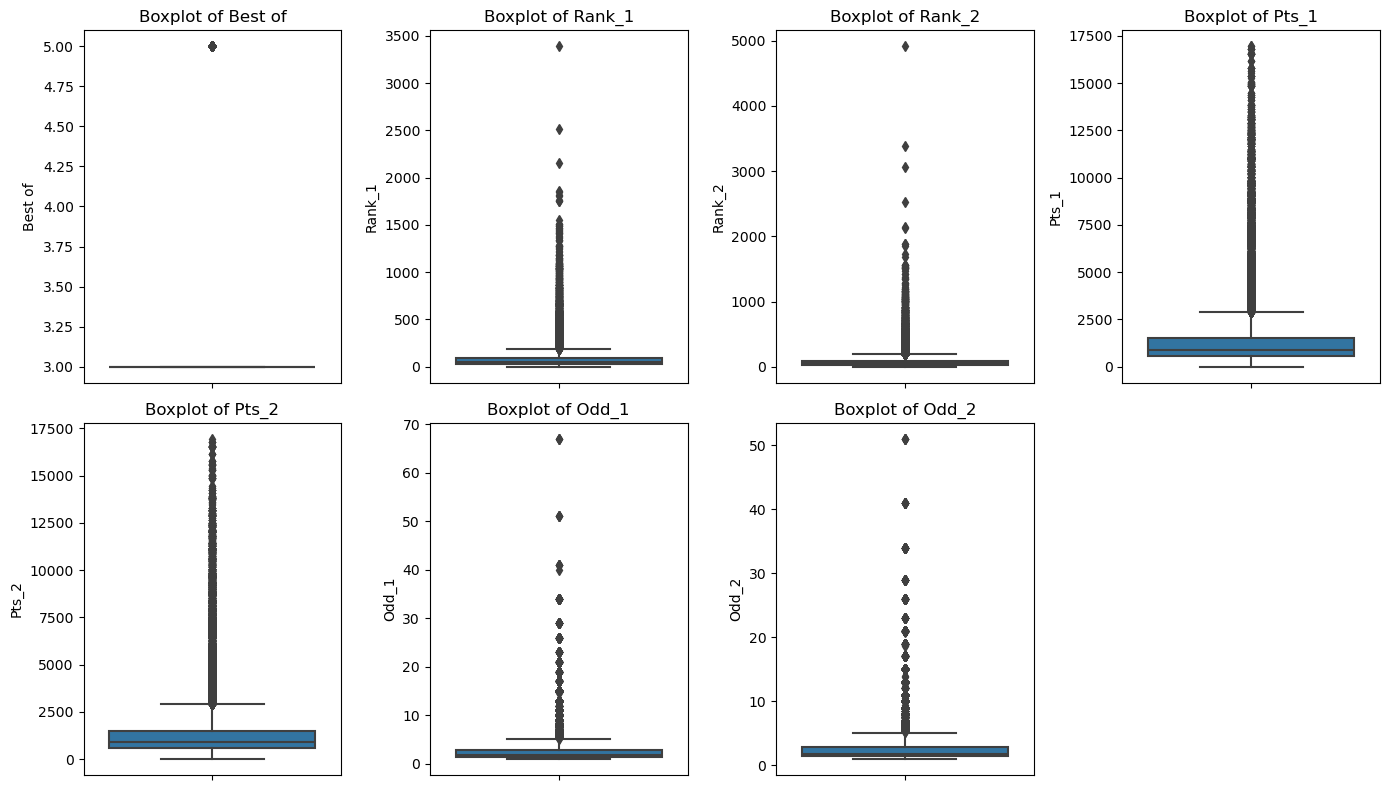

In [17]:
numeric_cols = ['Best of', 'Rank_1', 'Rank_2', 'Pts_1', 'Pts_2', 'Odd_1', 'Odd_2']

# Creating boxplots for each numeric column
plt.figure(figsize=(14, 8))
for i, col in enumerate(numeric_cols):
    plt.subplot(2, 4, i + 1)
    sns.boxplot(y=df[col])
    plt.title(f'Boxplot of {col}')

plt.tight_layout()
plt.show()

## **Results and Findings**

$\newline$
The descriptive statistics of the data below exhibits notable skewness, with a high concentration of values near the lower range and significant outliers in all variables, as shown by the boxplots. Measures of central tendency reveal moderate values for rankings and points, with mean values approximately 75 for both players in a match and average points of 1480. It is noted that on average that the number of points is greater for the second player, though they appear to have similar rankings on average. The odds variables also display high variability with a standard deviation of 2.59 and 2.57, suggesting considerable differences in betting expectations across matches. The boxplots and tables show the presence of extreme values, that skew the mean; this is evident when looking at the median values where the ranking is approximately 53 and the points are 585. The presence of extreme values in the odds may indicate occasional matches with unusually high stakes or lower-ranked players achieving significant wins. The analysis of player rankings across different court surfaces reveals that players achieve the highest average rank on carpet courts (63 for Rank_1 and 62 for Rank_2), followed by hard courts (72 and 71), while clay and grass surfaces exhibit higher average ranks (80 and 81 for clay, 84 and 83 for grass). This connotes that players may perform differently depending on the court surface, with carpet courts favoring higher-ranked players more consistently.

As expected, it seems that "Best_of" only sit at 2 values, 3 and 5, with 3 being roughly the mean. Each rank, pts and odd variable has quite a large variation in values.

Let's also check out the average rank by court surface.

In [18]:
df.groupby('Surface')[['Rank_1', 'Rank_2']].describe()

Rank_1                                                        \
           count       mean         std  min   25%   50%   75%     max   
Surface                                                                  
Carpet    1004.0  69.743028   88.556721  1.0  24.0  49.0  81.0   807.0   
Clay     16856.0  80.511569  105.168083  1.0  28.0  58.0  96.0  3390.0   
Grass     5975.0  81.837322  105.026503  1.0  27.5  57.0  97.0  2159.0   
Hard     29107.0  71.556327   98.518980  1.0  22.0  49.0  87.0  1855.0   

          Rank_2                                                        
           count       mean         std  min   25%   50%   75%     max  
Surface                                                                 
Carpet    1004.0  69.703187   86.513962  1.0  25.0  49.0  80.0   843.0  
Clay     16856.0  81.632594  117.417787  1.0  28.0  59.0  97.0  4915.0  
Grass     5975.0  80.611715   94.748329  1.0  28.0  60.0  99.0  1472.0  
Hard     29107.0  70.590270   94.642311  1.0  21.0  49.0  87.0  2146.0

It seems like the surface with the highest rank is carpet at 63, followed by hard at 72, and Clay and Grass at 80 and 85 respectively.

In [19]:
df.to_csv('./data/atp_tennis_clean.csv', index=False)